# https://github.com/salennon/huygens_simulator

## Good links:

Explains __ innit __ and self. for classes: https://www.reddit.com/r/learnpython/comments/z7ea9b/can_someone_explain_to_me_what_is_self_and_init/

Python classes: https://www.w3schools.com/python/python_classes.asp

In [1]:
'''
Classes to simulate wavelets of Huygens principle
'''
import matplotlib.pyplot as plt
import numpy as np
import os

from matplotlib.animation import FuncAnimation
from matplotlib import animation
from IPython.display import HTML

class Wavelet():
    '''
    Represent a single wavelet of Huygens' principle
    '''

    def __init__(self, ang_frequency, wave_vector, 
                position, amplitude = 1.0, phase = 0.0): # Sets up wave properties for all the below
        self.ang_frequency = ang_frequency
        self.wave_vector = wave_vector
        self.phase = phase # Phase offset
        self.amplitude = amplitude
        self.position = position # (x,y) co-ords of wavelet centre


    def field(self, time, x_mesh, y_mesh):
        '''
        Calculate field from wavelet at given time using given x and y 
        co-ordinates in x_mesh and y_mesh arrays.

        Field is calculated according to:
        E(r,t) = A*cos[k*(r-r0) - wt + phi]

        Where:
        E is the field
        A is amplitude
        k is wave vector = 2pi/lambda (ie, change in lambda = change in k) ; make this variable?
        r is general position co-ordinate (source)
        r0 is wavelet position (point of observation)
        w is angular frequency (keep constant)
        phi is phase (keep constant)
        r-r0 is the displacement vector from the wavelet (distance between screen and aperture)

        The values of the field as a function of position are returned
        '''
        #Calculate displacement co-ords relative to wavelet location
        x_displacement = x_mesh - self.position[0]
        y_displacement = y_mesh - self.position[1]
        displacement = (x_displacement**2 + y_displacement**2)**0.5

        field = self.amplitude*np.cos(self.wave_vector*displacement - \
                self.ang_frequency*time + self.phase)

        return field


    def __str__(self):
        return f'Wavelet at co-ords {self.position}'


class Simulator():
    '''
    Handle simulation of given wavelets

    The simulation is a superposition (i.e. the sum) of the fields of all the 
    wavelets
    '''

    def __init__(self, wavelets, x, y):
        '''
        Init with a given list of wavelet objects
        x and y should be arrays to define simulation region
        '''
        self.wavelets = wavelets
        self.x = x
        self.y = y

        #Generate co-ordinate mesh
        self.x_mesh, self.y_mesh = np.meshgrid(x, y)
        assert self.x_mesh.shape == self.y_mesh.shape, \
                'X mesh and Y mesh should have the same shape'
        self.mesh_shape = self.x_mesh.shape


    def frame(self, time):
        '''Get frame of simulation at a given time point'''
        field = np.zeros(self.mesh_shape)

        #Sum contributions from each wavelet
        for wavelet in self.wavelets:
            field += wavelet.field(time, self.x_mesh, self.y_mesh)

        return field


    def animate(self, fig, ax, start, stop, time_step, filename):
        '''
        Simulate fields and generate animation over given timeframe between 
        start and stop with given time_step. 
        Animation is drawn on given figure and axis, and saved to filename

        TODO:
        Formatting of axes etc. - check these can be done externally to the 
        method
        '''
        time_points = np.arange(start, stop, time_step)

        #Use first frame to set z scale
        extent = (min(self.x), max(self.x), min(self.y), max(self.y))
        im = ax.imshow(self.frame(time_points[0]), cmap = 'RdBu', extent = extent,
                        origin = 'lower')
        
        #Formatting
        fig.colorbar(im)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        
        def generate_frame(i):
            '''Generate each frame of the animation using frame index i'''
            self.print_progress(i, num_frames)
            field = self.frame(time_points[i])
            im.set_array(field)
            return im,        #FuncAnimation requires iterable returned

        #Simulate + generate animation
        num_frames = len(time_points)
        print(f'\nGenerating Animation of {num_frames} frames.\nSimulating...\n')
        anim = FuncAnimation(fig, generate_frame, frames = num_frames)
        anim.save(filename, fps = 60)
        print(f'\nAnimation saved to {filename}\n')


    def simulate(self, start, stop, time_step):
        '''
        Simulate fields between start and stop time, with given time step.
        Results returned as a 3D array

        animate method is preferred at this point, which calculates each frame
        then, animates (so should require less memory usage)

        TODO:
        Test this method
        '''
        time_points = np.arange(start, stop, time_step)
        y_dim = self.mesh_shape[0]
        x_dim = self.mesh_shape[1]
        t_dim = len(time_points)
        result = np.empty((t_dim, y_dim, x_dim), dtype='float32')

        for i, time in enumerate(time_points):
            self.print_progress(i, t_dim)
            field = self.frame(time)
            result[i] = field
        
        return result


    @staticmethod
    def print_progress(i, num_frames, interval = 10):
        '''
        Print progress at given interval during simulation etc.
        i is the current frame index
        '''
        fr_num = i+1    #Convert from 0 indexed to 1
        if fr_num % interval == 0 or fr_num == num_frames:
            print(f'{fr_num}/{num_frames}')


    def __str__(self):
        rep = f'Huygens simulator with {len(self.wavelets)} wavelet(s):'
        for wavelet in self.wavelets:
            rep += f'\n{wavelet.__str__()}'
        return rep
        

def main():
    print('''
        huygens.py is a module containing classes to perform a 2D simulation of
        Huygens-Fresnel Principle - summing the contributions of multiple 
        spherical wavelets to generate a resultant wavefront

        Usage:
        Simulator instance handles the simulation - provide this with an
        iterable of wavelets (see Wavelet class) to be simulated, plus 
        simulation settings.
        Wavelet class handles each wavelet - initialize these first to be used
        by Simulator.

        ''')


if __name__ == '__main__':
    main()



    


        huygens.py is a module containing classes to perform a 2D simulation of
        Huygens-Fresnel Principle - summing the contributions of multiple 
        spherical wavelets to generate a resultant wavefront

        Usage:
        Simulator instance handles the simulation - provide this with an
        iterable of wavelets (see Wavelet class) to be simulated, plus 
        simulation settings.
        Wavelet class handles each wavelet - initialize these first to be used
        by Simulator.

        


In [2]:
'''
Simulate diffraction from a single slit
'''


print('\nSingle slit simulation\n')

#Wavelet parameters
wavelength = 4.0
period = 0.2
ang_frequency = 2*np.pi/period
wave_vector = 2*np.pi/wavelength

#Wavelet positions
x_pos = -50
y_pos_min = -10 #Slit height = 20, so positions from -10 to +10
y_pos_max = 10
num_wavelets = 20 #Number of wavelets to simulate across slit height
positions = [(x_pos, y_pos) for y_pos in \
            np.linspace(y_pos_min, y_pos_max, num_wavelets)]

#Define wavelet(s) in simulation
wavelets = [Wavelet(ang_frequency, wave_vector, position) for position in
            positions]

#Simulation region (ie, screen)
x_min, x_max = -50, 50
y_min, y_max = -50, 50
x_res, y_res = 0.1, 0.1
x = np.arange(x_min, x_max, x_res)
y = np.arange(y_min, y_max, y_res)

#Simulation time settings
start = 0.0
num_of_periods = 1                #Number of wavelet periods to record for
time_steps_per_period = 30
stop = start + num_of_periods*period
time_step = period/time_steps_per_period

#Initialize simulator
simulator = Simulator(wavelets, x, y)
"""print(simulator)"""

#Generate simulation and animation
fig, ax = plt.subplots()
ax.set_title('Single slit')
extent = (min(x), max(x), min(y), max(y))
time_points = np.arange(start, stop, time_step)
im = ax.imshow(simulator.frame(time_points[0]), cmap = 'RdBu', extent = extent, origin = 'lower')
fig.colorbar(im)
ax.set_xlabel('x')
ax.set_ylabel('y')

def update(i):
    field = simulator.frame(time_points[i])
    im.set_array(field)
    return [im]

    #FuncAnimation requires iterable returned

ani = animation.FuncAnimation(fig, update, frames = len(time_points), blit = True)
plt.close(fig)

HTML(ani.to_jshtml())



Single slit simulation



# https://www.geeksforgeeks.org/python/single-slit-diffraction-pattern-using-python/

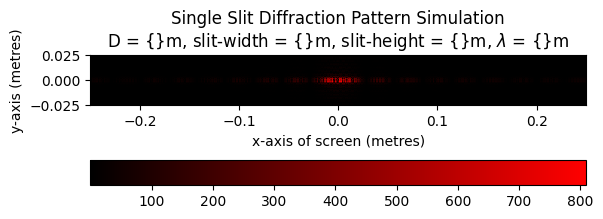

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors


# ADJUSTABLE VARIABLES, defining the setup (Units : SI)
D = 5           # distance of screen
slitWidth = 0.0001
slitHeight = 0.005
# amplitude/intensity
a = 1 
# wavelength
w = 0.0000006   
x1 = -0.25      
# assuming screen is a rectangle from (x1,y1) to (x2,y2)
x2 = 0.25
y1 = -0.025
y2 = 0.025
# linear resolution (no. of points per unit length)
lres = 5000  


# PERFORMING CALCULATIONS
# calculations are performed using numpy arrays and array methods
n, m = int((x2-x1)*lres), int((y2-y1)*lres)

# Obtaining sample points on the screen -
# X, Y and Z are mxn 2d arrays containing x coordinates, y coordinates
# and z coordinates of the screen sample-points respectively.
X = np.linspace(x1, x2, n)
Y = np.linspace(y1, y2, m)
X, Y = np.meshgrid(X, Y)
Z = np.ones((m, n))*D


# Dividing the slit into sample points
# xcoords contains the x coordinates of the sample points
# ycoords contains the y coordinates of the sample points
xcoords = np.linspace(-slitWidth/2, slitWidth/2, 20)
ycoords = np.linspace(-slitHeight/2, slitHeight/2, 100)

# calculating the amplitude/intensity at each point (using superposition)
# first the intensity is initialised as zero
# then the intensity due to each sample point on the slit is added in the loop
A = np.zeros((m, n))
for i in ycoords:
    for j in xcoords:
        L = np.sqrt(np.square(X-np.ones((m, n))*j) +
                    np.square(Y-np.ones((m, n))*i) + np.square(Z))
        theta = (L/w) * 2 * np.pi
        A += a * np.sin(theta)

A = np.abs(A)


# PLOTTING
# following steps set the axes, labels and title
ax = plt.axes()
ax.set_aspect('equal')
plt.rc('text', usetex=False)   # this tells matplotlib that tex has been used in titles and labels
plt.title("Single Slit Diffraction Pattern Simulation\nD = {}m, slit-width = {}m, slit-height = {}m, $\lambda$ = {}m")
plt.xlabel("x-axis of screen (metres)")
plt.ylabel("y-axis (metres)")

# follwing step plots the heatmap of 2D-array A
graph = plt.pcolormesh(
    X, Y, A, cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black', 'red']))

# following step adds the scale of the heatmap to the figure
plt.colorbar(graph, orientation='horizontal')
plt.show()